# Lecture 11: Training a Quantum Machine Learning Model

### A Variational Quantum Classifier (VQC) in PennyLane

In Lectures 1–10 we built up the linear algebra of quantum computing: complex
amplitudes, vectors (qubit states), inner products, the Bloch sphere, tensor
products (multi-qubit systems), matrices, and finally quantum **gates** as
unitary matrices. This lecture puts all of that to work on a concrete task:
**training a quantum model to classify data.**

A *variational quantum classifier* is a **hybrid quantum–classical** algorithm.
The pattern is:

1. **Encode** a classical data point $\mathbf{x}$ into a quantum state (a *feature map*).
2. **Transform** it with a parameterized circuit $U(\boldsymbol\theta)$ — the *ansatz* —
   built from the same rotation and entangling gates from Lecture 10.
3. **Measure** an observable to get a prediction.
4. **Optimize** the parameters $\boldsymbol\theta$ with classical gradient descent so the
   predictions match the labels.

Steps 1–3 run on a quantum device (here, a simulator); step 4 runs classically.
This is exactly the template used across the modern QML ecosystem
([PennyLane demos](https://pennylane.ai/qml/demonstrations), 
[qiskit-machine-learning](https://github.com/qiskit-community/qiskit-machine-learning)).

## Imports and dependencies

We use [PennyLane](https://pennylane.ai/) (introduced in Lecture 7) for the
quantum model, and `scikit-learn` for a small dataset. PennyLane ships its own
wrapped version of NumPy that knows how to differentiate through quantum
circuits — this is what makes training possible.

In [1]:
import pennylane as qml
from pennylane import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

np.random.seed(42)
print('PennyLane version:', qml.__version__)

PennyLane version: 0.45.1


## The dataset

We use the classic **two-moons** dataset: two interleaving half-circles that are
*not* linearly separable, so the model has to learn a curved decision boundary.

Two preprocessing steps matter for a quantum model:

- We scale each feature into $[0, \pi]$ so it can be used directly as a **rotation
  angle** when we encode the data into qubits.
- We map the labels from $\{0, 1\}$ to $\{-1, +1\}$, because we will read out a
  prediction from the expectation value $\langle Z \rangle \in [-1, +1]$ of a qubit.

train: (140, 2)   test: (60, 2)


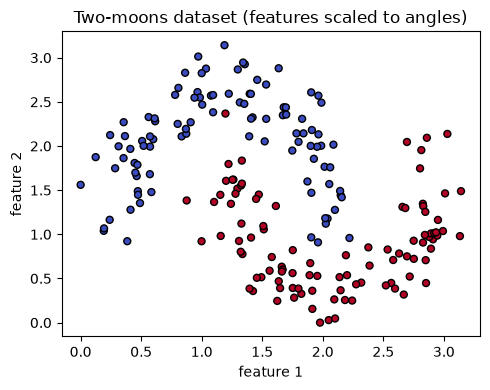

In [2]:
X, y = make_moons(n_samples=200, noise=0.15, random_state=42)
y = 2 * y - 1                       # {0,1} -> {-1,+1}
X = MinMaxScaler(feature_range=(0, np.pi)).fit_transform(X)   # features -> angles

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42)
print('train:', X_train.shape, '  test:', X_test.shape)

plt.figure(figsize=(5, 4))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolors='k', s=25)
plt.title('Two-moons dataset (features scaled to angles)')
plt.xlabel('feature 1'); plt.ylabel('feature 2'); plt.tight_layout()
plt.show()

## Step 1 & 2: the quantum circuit (feature map + ansatz)

We use **2 qubits** — one per feature.

- **Feature map** `AngleEmbedding`: rotates each qubit by its feature value.
  This is the data-encoding map $\mathbf{x} \mapsto |\phi(\mathbf{x})\rangle$, built from the
  single-qubit rotations of Lecture 10.
- **Ansatz** `StronglyEntanglingLayers`: alternating layers of trainable rotations
  and CNOT-style entangling gates (Lecture 10's controlled gates, Lecture 9's
  tensor-product structure). The trainable parameters live here.

We measure $\langle Z \rangle$ on the first qubit as the raw model output.

In [3]:
n_qubits = 2
n_layers = 3
dev = qml.device('default.qubit', wires=n_qubits)

@qml.qnode(dev)
def circuit(weights, x):
    qml.AngleEmbedding(x, wires=range(n_qubits), rotation='Y')   # encode data
    qml.StronglyEntanglingLayers(weights, wires=range(n_qubits)) # trainable ansatz
    return qml.expval(qml.PauliZ(0))                             # measure <Z>

# A trainable bias shifts the decision threshold (a classical parameter).
def variational_classifier(weights, bias, x):
    return circuit(weights, x) + bias

Let's draw the circuit so we can see the gates produced by the feature map and
the first entangling layer:

In [4]:
shape = qml.StronglyEntanglingLayers.shape(n_layers=n_layers, n_wires=n_qubits)
demo_weights = 0.1 * np.random.randn(*shape)
print(qml.draw(circuit)(demo_weights, X_train[0]))

0: ─╭AngleEmbedding(M0)─╭StronglyEntanglingLayers(M1)─┤  <Z>
1: ─╰AngleEmbedding(M0)─╰StronglyEntanglingLayers(M1)─┤     

M0 = 
[0.94046681 2.54750493]
M1 = 
[[[ 0.05437432 -0.06154298 -0.11978064]
  [ 0.21416584 -0.0094621  -0.09288281]]

 [[-0.08852303 -0.04121885 -0.04826188]
  [ 0.01641648  0.02330952  0.01179946]]

 [[ 0.14623781  0.1538715  -0.24391058]
  [ 0.06034412 -0.0251044  -0.01638671]]]


## Step 3: loss and accuracy

We train with a simple **square loss** between the labels and the model output,
and track **accuracy** by taking the sign of the prediction.

In [5]:
def square_loss(labels, preds):
    return np.mean((labels - qml.math.stack(preds)) ** 2)

def accuracy(weights, bias, X, Y):
    preds = [np.sign(variational_classifier(weights, bias, x)) for x in X]
    return np.mean(np.array(preds) == Y)

def cost(weights, bias, X, Y):
    preds = [variational_classifier(weights, bias, x) for x in X]
    return square_loss(Y, preds)

## Step 4: the hybrid training loop

This is the heart of QML. Each iteration:

1. samples a mini-batch,
2. evaluates the circuit (quantum),
3. computes the gradient of the loss **with respect to the circuit parameters**
   — PennyLane differentiates through the quantum circuit automatically,
4. takes an Adam optimizer step (classical).

The parameters slowly converge to values that make the quantum model separate
the two moons.

In [6]:
weights = 0.01 * np.random.randn(*shape, requires_grad=True)
bias = np.array(0.0, requires_grad=True)
opt = qml.AdamOptimizer(stepsize=0.1)
batch_size = 16

history = []
for it in range(35):
    idx = np.random.randint(0, len(X_train), (batch_size,))
    X_batch, y_batch = X_train[idx], y_train[idx]
    weights, bias = opt.step(lambda w, b: cost(w, b, X_batch, y_batch), weights, bias)

    c = cost(weights, bias, X_train, y_train)
    acc = accuracy(weights, bias, X_train, y_train)
    history.append((float(c), float(acc)))
    if it % 5 == 0 or it == 34:
        print(f'iter {it:2d} | cost {c:.4f} | train acc {acc:.2f}')

iter  0 | cost 1.9979 | train acc 0.29


iter  5 | cost 1.4374 | train acc 0.48


iter 10 | cost 0.8958 | train acc 0.59


iter 15 | cost 0.5197 | train acc 0.85


iter 20 | cost 0.4725 | train acc 0.86


iter 25 | cost 0.4988 | train acc 0.81


iter 30 | cost 0.4629 | train acc 0.84


iter 34 | cost 0.4406 | train acc 0.85


## Evaluation

We check accuracy on the held-out test set and visualize the learned decision
boundary by classifying every point on a grid.

Test accuracy: 0.87


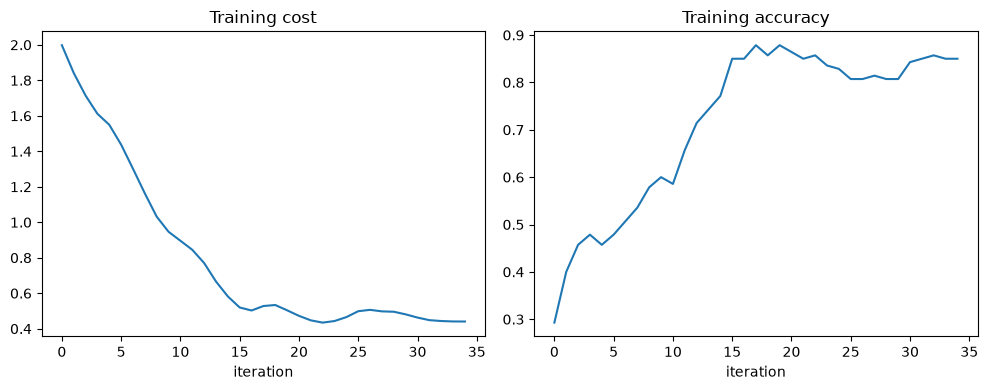

In [7]:
test_acc = accuracy(weights, bias, X_test, y_test)
print(f'Test accuracy: {test_acc:.2f}')

# cost / accuracy curves
hist = np.array(history)
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].plot(hist[:, 0]); ax[0].set_title('Training cost'); ax[0].set_xlabel('iteration')
ax[1].plot(hist[:, 1]); ax[1].set_title('Training accuracy'); ax[1].set_xlabel('iteration')
plt.tight_layout(); plt.show()

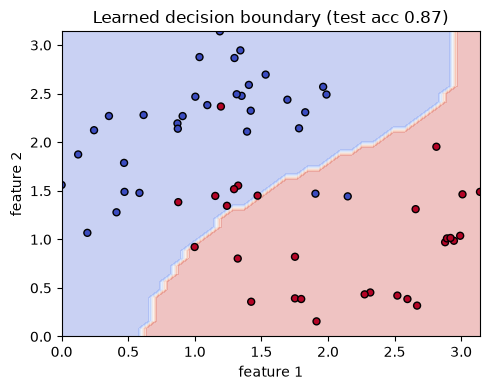

In [8]:
# Decision boundary
xx, yy = np.meshgrid(np.linspace(0, np.pi, 40), np.linspace(0, np.pi, 40))
grid = np.c_[xx.ravel(), yy.ravel()]
Z = np.array([np.sign(variational_classifier(weights, bias, g)) for g in grid])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(5, 4))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap='coolwarm', edgecolors='k', s=25)
plt.title(f'Learned decision boundary (test acc {test_acc:.2f})')
plt.xlabel('feature 1'); plt.ylabel('feature 2'); plt.tight_layout()
plt.show()

## Where to go next

You just trained a quantum model end-to-end. The same template generalizes in
many directions — good starting points for further projects:

- **More expressive models:** more qubits/layers, different feature maps
  (`AmplitudeEmbedding`, data re-uploading), or other ansatze.
- **Real datasets & benchmarking:** 
  [XanaduAI/qml-benchmarks](https://github.com/XanaduAI/qml-benchmarks) provides a
  standardized harness, and [QDataSet](https://github.com/eperrier/QDataSet)
  offers ready-made quantum datasets.
- **Other frameworks:** rebuild this in
  [qiskit-machine-learning](https://github.com/qiskit-community/qiskit-machine-learning)
  to compare.
- **Hardware:** swap `default.qubit` for a real-device backend.

## Exercises

1. Increase `n_layers` to 6 and `n_qubits` to 3. Does test accuracy improve, or
   does the model overfit? Plot the cost curve.
2. Replace the square loss with a hinge loss and compare convergence.
3. Swap `make_moons` for `make_circles` (concentric circles). What changes in the
   decision boundary?
4. Try `qml.GradientDescentOptimizer` instead of Adam. How does the learning rate
   affect training?
5. Re-encode the data with `rotation='X'` instead of `'Y'`. Why might the choice
   of encoding axis matter (hint: revisit the Bloch sphere, Lecture 5)?